<div style="background-image: url('https://www.dropbox.com/scl/fi/nwtuyf23tzyuq9gfan3oc/mcnair.jpg?rlkey=4t1of5cy6bfgxn6xck7yu9hvo&dl=1'); background-size: cover; background-position: center; height: 300px; display: flex; align-items: center; justify-content: center; color: white; text-shadow: 2px 2px 4px rgba(0,0,0,0.7); margin-bottom: 20px; position: relative;">
  <h1 style="text-align: center; font-size: 2.5em; margin: 0;">JGSB Python Workshop <br> Part 14: Neural Networks </h1>
  <div style="position: absolute; bottom: 10px; left: 15px; font-size: 0.9em; color: white; text-shadow: 2px 2px 4px rgba(0,0,0,0.7);">
    Authored by Kerry Back
  </div>
  <div style="position: absolute; bottom: 10px; right: 15px; text-align: right; font-size: 0.9em; color: white; text-shadow: 2px 2px 4px rgba(0,0,0,0.7);">
    Rice University, 2025
  </div>
</div>

In [34]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducible results
np.random.seed(42)

### Overview

We will illustrate machine learning with python by training and testing a neural network for image classification.  

Gemini will do all the work.

Following the illustration, there is a brief explanation of how neural networks work.

### Task

Classify hand-written numbers (digits 0 through 9).  This is a simple task and is a standard example for introducing machine learning concepts.

The data is in the scikit-learn library and is loaded and described in the next cell.

The original handwritten digits were pixelated into 64 pixels (8 x 8).  Each observation in the data set consists of 65 numbers: the true digit and the darkness values of each of the 64 pixels.  The darkness values range from 0 (white = no ink) to 16 (black = heavy ink).

Digits Dataset:
  Total samples: 1,797
  Features per sample: 64 (8×8 pixels)
  Classes: 10 (digits 0-9)
  Feature range: [0.0, 16.0]


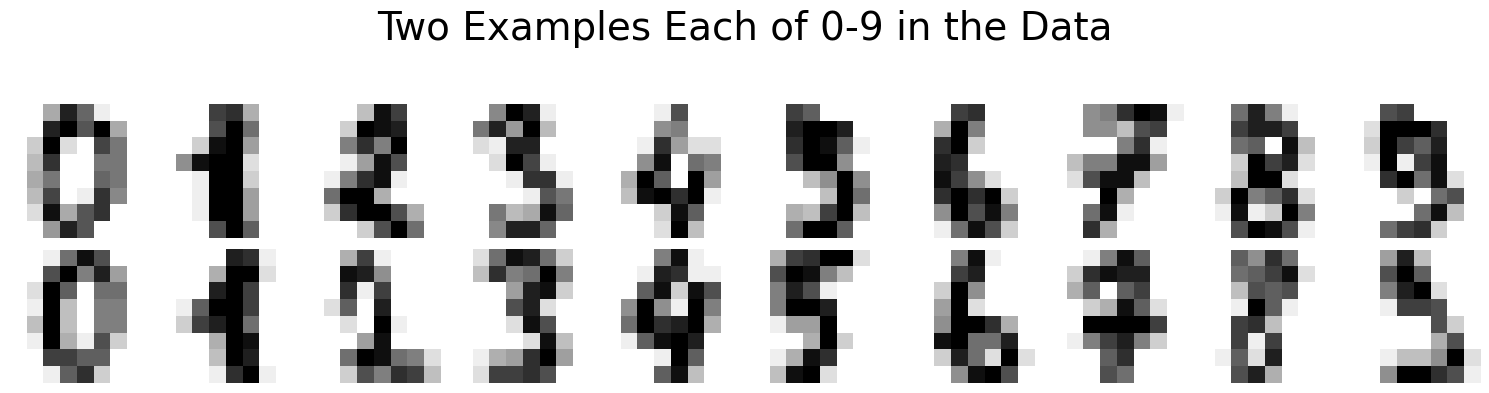

In [35]:
# Load the digits dataset
digits = load_digits()
X = digits.data  # 8x8 images flattened to 64 features
y = digits.target  # Digit labels 0-9

print(f"Digits Dataset:")
print(f"  Total samples: {X.shape[0]:,}")
print(f"  Features per sample: {X.shape[1]} (8×8 pixels)")
print(f"  Classes: {len(np.unique(y))} (digits 0-9)")
print(f"  Feature range: [{X.min():.1f}, {X.max():.1f}]")

# Show some example digits
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for digit in range(10):
    # Find first occurrence of each digit
    idx = np.where(y == digit)[0][0]
    
    # Original image
    axes[0, digit].imshow(X[idx].reshape(8, 8), cmap='gray_r')
    axes[0, digit].axis('off')
    
    # Show another example
    idx2 = np.where(y == digit)[0][1]  # Second occurrence
    axes[1, digit].imshow(X[idx2].reshape(8, 8), cmap='gray_r')
    axes[1, digit].axis('off')

plt.suptitle('Two Examples Each of 0-9 in the Data', fontsize=28, y=1.02)
plt.tight_layout()
plt.show()


### Exercise

**1.** Ask Gemini to do a train-test split on X and y defined in the previous cell.
**2.** Ask Gemini to train a multilayer perceptron on the training data to predict y from X.
**3.** Ask Gemini to evaluate the performance of the model on the test data.
**4.** Ask Gemini to create and explain the confusion matrix for both the training data and the test data.
**5.** Ask Gemini for suggestions on how to improve the model.
**6.** Ask Gemini to implement at least one of the situations and repeat #3 and #4.

### Understanding Neural Networks: A Simple Example

Imagine you're analyzing customer data and want to predict purchase behavior. You have:
- **Input 1 (x₁)**: Customer age (normalized)
- **Input 2 (x₂)**: Customer income (normalized) 
- **Target**: 1 if customer purchases, 0 if not

For our example, we'll create the target values by assuming customers usually purchase when `age + income ≥ 0` (after normalization).  But, we'll assume this rule does not always hold by adding some noise.

The following cell generates some data and illustrates it.

Customer Data Sample:
   age_normalized  income_normalized  purchase
0       -0.501840           0.568127         1
1        1.802857          -1.663440         1
2        0.927976          -1.353485         1
3        0.394634           1.594217         1
4       -1.375925           0.425716         0


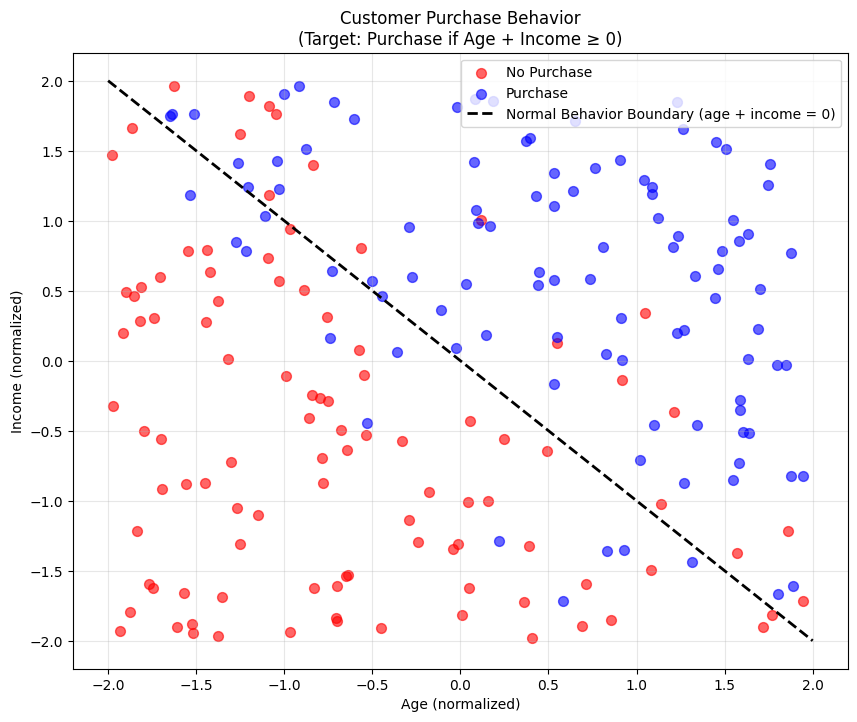


Data Summary:
Total customers: 200
Customers who purchased: 100 (50.0%)
Customers who didn't purchase: 100 (50.0%)


In [36]:
# Generate sample customer data
np.random.seed(42)
n_customers = 200

# Generate random age and income (normalized to range [-2, 2])
x1_age = np.random.uniform(-2, 2, n_customers)
x2_income = np.random.uniform(-2, 2, n_customers)

# True target: purchase if age + income >= 0 (with some noise)
noise = np.random.normal(0, 1, n_customers)  # Add realistic noise
true_score = x1_age + x2_income + noise
y_purchase = (true_score >= 0).astype(int)

# Create DataFrame for easy viewing
customer_data = pd.DataFrame({
    'age_normalized': x1_age,
    'income_normalized': x2_income, 
    'purchase': y_purchase
})

print("Customer Data Sample:")
print(customer_data.head())

# Visualize the data
plt.figure(figsize=(10, 8))
colors = ['red', 'blue']
labels = ['No Purchase', 'Purchase']

for i in [0, 1]:
    mask = y_purchase == i
    plt.scatter(x1_age[mask], x2_income[mask], c=colors[i], alpha=0.6, 
               label=labels[i], s=50)

# Draw the true decision boundary
x_line = np.linspace(-2, 2, 100)
y_line = -x_line  # age + income = 0 => income = -age
plt.plot(x_line, y_line, 'k--', linewidth=2, label='Normal Behavior Boundary (age + income = 0)')

plt.xlabel('Age (normalized)')
plt.ylabel('Income (normalized)')
plt.title('Customer Purchase Behavior\n(Target: Purchase if Age + Income ≥ 0)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nData Summary:")
print(f"Total customers: {n_customers}")
print(f"Customers who purchased: {np.sum(y_purchase)} ({np.mean(y_purchase):.1%})")
print(f"Customers who didn't purchase: {n_customers - np.sum(y_purchase)} ({1-np.mean(y_purchase):.1%})")

For this example, we'll use a very simple network structure.  The two input values will be passed to each of three **neurons**.  

A neuron is just a mathematical function.  Each neuron has coefficients (b, w1, w2).  b is called the bias parameter, w1 and w2 are weights.  Each neuron calculates a linear function **b + w1*x1 + w2*x2** (so b is the intercept).

The value of the linear function is then transformed by an **activation function.**  Standard examples are **sigmoid** and **ReLU**.  After applying the activation, call the result **h**.  

**sigmoid activation:**  calculate
$$ h = \frac{1}{1+ e^{-b - w_1x_2 - w_2x_2}}$$

**ReLU activation:** calculate
$$h = max(0, b + w_1x_1 + w_2x_2)$$

The parameters b, w1, and w2 of each neuron are fitted (trained) from the data, similar in spirit to running a regression model to find a line of best fit to data.

### Visualizing the Network

The following is an image of our network.  The values of x1 and x2 are passed to each of three neurons.  Each neuron has its own (b, w1, w2) parameters and calculates its own output h.

The output neuron receives the three h's.  Call them h1, h2, and h3.  The output neuron also has its own parameters.  They are (b, w1, w2, w3).  There are three weights, because it receives three h's.  The output neuron calculates either 

**sigmoid activation:**
$$\hat y = \frac{1}{1 + e^{-b - w_1h_1 - w_2h_2 - w_3h_3}}$$

or 

**ReLU activation:** ReLU is turned off for the output, so
$$\hat y = b + w_1h_1 + w_2h_2 + w_3h_3$$

In [ ]:
# Visualize the network structure
from IPython.display import Image, display

url = "https://raw.githubusercontent.com/kerryback/workshop_python/main/images/neural_network.png"
display(Image(url=url))  

print("\nNetwork Parameters")
print("• Total weights: 2×3 + 3×1 = 9 weights")
print("• Total biases: 3 + 1 = 4 biases")
print("• Total parameters: 13")


Network Parameters
• Total weights: 2×3 + 3×1 = 9 weights
• Total biases: 3 + 1 = 4 biases
• Total parameters: 13


EXAMPLE OF NETWORK CALCULATION (FORWARD PROPAGATION)

1. NETWORK PARAMETERS :
----------------------------------------
Coefficients:
  neuron for h1: b=0.1, w1=0.5, w1=0.3
  neuron for h2: b=-0.2, w1=-0.4, w2=0.6
  neuron for h3: b=0.3, w1=0.2, w2=-0.3
  output neuron: b=0.2, w1=0.7, w2=-0.5, w3=0.8

2. INPUT VALUES:
----------------------------------------
  x1 = 1.2
  x2 = -0.8

3. FORWARD PROPAGATION CALCULATIONS:
----------------------------------------

Step 1: Calculate Hidden Layer
  Formula: h = sigmoid(b + w1*·x1 + w2*x2)

  h1: sigmoid(0.5×1.2 + 0.3×(-0.8) + 0.1)
      = σ(0.460) = 0.613

  h2: sigmoid(-0.4×1.2 + 0.6×(-0.8) + -0.2)
      = σ(-1.160) = 0.239

  h3: sigmoid(0.2×1.2 + -0.3×(-0.8) + 0.3)
      = σ(0.780) = 0.686

Step 2: Calculate Output
  Formula: ŷ = σ(w₁·h₁ + w₂·h₂ + w₃·h₃ + b)

  ŷ: σ(0.7×0.613 + (-0.5)×0.239 + 0.8×0.686 + 0.2)
     = σ(1.058) = 0.742

4. FINAL RESULT:
----------------------------------------
  Input: x₁=1.2, x₂=-0.8
  Hidden: h₁=0.613, h₂=0.

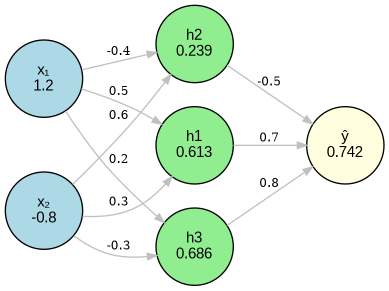


Diagram shows:
• Blue nodes: Input values (x₁=1.2, x₂=-0.8)
• Green nodes: Hidden layer activations after sigmoid
• Yellow node: Output prediction after sigmoid
• Edge labels: Weight values
• Node values: Actual computed values at each stage

SUMMARY
This network transforms inputs (1.2, -0.8) through:
1. Three hidden neurons with sigmoid activation
2. One output neuron with sigmoid activation
3. Final prediction: 0.742 (74.2% probability)

The network learned these weights through training (not shown here).
Different weights would produce different predictions.


In [45]:
# Concrete Example with Simple Values
print("="*60)
print("EXAMPLE OF NETWORK CALCULATION (FORWARD PROPAGATION)")
print("="*60)

# Define the sigmoid activation function
def sigmoid(z):
    """Sigmoid activation function: converts any real number to (0,1)"""
    z = np.clip(z, -500, 500)  # Prevent overflow
    return 1 / (1 + np.exp(-z))

# Define simple weights and biases 
print("\n1. NETWORK PARAMETERS :")
print("-" * 40)

# Input to Hidden Weights
W1 = np.array([
    [0.5, 0.3],    # h1 weights: [x1_weight, x2_weight]
    [-0.4, 0.6],   # h2 weights
    [0.2, -0.3]    # h3 weights
])

# Hidden biases
b1 = np.array([0.1, -0.2, 0.3])

# Hidden to Output Weights
W2 = np.array([[0.7], [-0.5], [0.8]])

# Output bias
b2 = np.array([0.2])

print("Coefficients:")
print(f"  neuron for h1: b={b1[0]}, w1={W1[0,0]}, w1={W1[0,1]}")
print(f"  neuron for h2: b={b1[1]}, w1={W1[1,0]}, w2={W1[1,1]}")
print(f"  neuron for h3: b={b1[2]}, w1={W1[2,0]}, w2={W1[2,1]}")
print(f"  output neuron: b={b2[0]}, w1={W2[0,0]}, w2={W2[1,0]}, w3={W2[2,0]}")

# Example input values
x1_val = 1.2
x2_val = -0.8
x_input = np.array([x1_val, x2_val])

print(f"\n2. INPUT VALUES:")
print("-" * 40)
print(f"  x1 = {x1_val}")
print(f"  x2 = {x2_val}")

# Step-by-step calculation
print(f"\n3. FORWARD PROPAGATION CALCULATIONS:")
print("-" * 40)

# Calculate hidden layer
print("\nStep 1: Calculate Hidden Layer")
print("  Formula: h = sigmoid(b + w1*·x1 + w2*x2)")
print()

z1_vals = W1 @ x_input + b1
h_vals = sigmoid(z1_vals)

for i in range(3):
    calc_str = f"  h{i+1}: sigmoid({W1[i,0]}×{x1_val} + {W1[i,1]}×({x2_val}) + {b1[i]})"
    z_val = W1[i,0]*x1_val + W1[i,1]*x2_val + b1[i]
    h_val = sigmoid(z_val)
    print(f"{calc_str}")
    print(f"      = σ({z_val:.3f}) = {h_val:.3f}")
    print()

# Calculate output
print("Step 2: Calculate Output")
print("  Formula: ŷ = σ(w₁·h₁ + w₂·h₂ + w₃·h₃ + b)")
print()

z2_val = W2.T @ h_vals + b2
y_hat = sigmoid(z2_val)[0]

calc_str = f"  ŷ: σ({W2[0,0]}×{h_vals[0]:.3f} + ({W2[1,0]})×{h_vals[1]:.3f} + {W2[2,0]}×{h_vals[2]:.3f} + {b2[0]})"
z_final = W2[0,0]*h_vals[0] + W2[1,0]*h_vals[1] + W2[2,0]*h_vals[2] + b2[0]
print(f"{calc_str}")
print(f"     = σ({z_final:.3f}) = {y_hat:.3f}")

print(f"\n4. FINAL RESULT:")
print("-" * 40)
print(f"  Input: x₁={x1_val}, x₂={x2_val}")
print(f"  Hidden: h₁={h_vals[0]:.3f}, h₂={h_vals[1]:.3f}, h₃={h_vals[2]:.3f}")
print(f"  Output: ŷ={y_hat:.3f}")
print(f"\n  Interpretation: {y_hat:.1%} probability of positive outcome")
print(f"  Decision: {'Purchase' if y_hat >= 0.5 else 'No Purchase'} (threshold = 0.5)")

# Create pydot diagram with actual values
try:
    import pydot
    from IPython.display import Image, display
    
    # Create a new directed graph
    graph = pydot.Dot(graph_type='digraph', rankdir='LR', bgcolor='white')
    graph.set_node_defaults(shape='circle', style='filled', fontname='Arial', fontsize='11')
    graph.set_edge_defaults(color='gray', arrowsize='0.7', fontsize='9')
    
    # Input layer nodes with values
    x1_node = pydot.Node('x1', label=f'x₁\n{x1_val}', fillcolor='lightblue', width='0.8')
    x2_node = pydot.Node('x2', label=f'x₂\n{x2_val}', fillcolor='lightblue', width='0.8')
    graph.add_node(x1_node)
    graph.add_node(x2_node)
    
    # Hidden layer nodes with calculated values
    for i in range(3):
        node = pydot.Node(f'h{i+1}', 
                         label=f'h{i+1}\n{h_vals[i]:.3f}', 
                         fillcolor='lightgreen', 
                         width='0.8')
        graph.add_node(node)
    
    # Output node with final value
    output_node = pydot.Node('y', 
                            label=f'ŷ\n{y_hat:.3f}', 
                            fillcolor='lightyellow', 
                            width='0.8')
    graph.add_node(output_node)
    
    # Add edges with weights as labels
    # Input to hidden
    graph.add_edge(pydot.Edge('x1', 'h1', label=f'{W1[0,0]}'))
    graph.add_edge(pydot.Edge('x1', 'h2', label=f'{W1[1,0]}'))
    graph.add_edge(pydot.Edge('x1', 'h3', label=f'{W1[2,0]}'))
    graph.add_edge(pydot.Edge('x2', 'h1', label=f'{W1[0,1]}'))
    graph.add_edge(pydot.Edge('x2', 'h2', label=f'{W1[1,1]}'))
    graph.add_edge(pydot.Edge('x2', 'h3', label=f'{W1[2,1]}'))
    
    # Hidden to output
    graph.add_edge(pydot.Edge('h1', 'y', label=f'{W2[0,0]}'))
    graph.add_edge(pydot.Edge('h2', 'y', label=f'{W2[1,0]}'))
    graph.add_edge(pydot.Edge('h3', 'y', label=f'{W2[2,0]}'))
    
    # Save the graph
    import os
    os.makedirs('../images', exist_ok=True)
    graph.write_png('../images/neural_network_with_values.png')
    
    print("\n5. NETWORK DIAGRAM WITH VALUES:")
    print("-" * 40)
    display(Image('../images/neural_network_with_values.png'))
    print("\nDiagram shows:")
    print("• Blue nodes: Input values (x₁=1.2, x₂=-0.8)")
    print("• Green nodes: Hidden layer activations after sigmoid")
    print("• Yellow node: Output prediction after sigmoid")
    print("• Edge labels: Weight values")
    print("• Node values: Actual computed values at each stage")
    
except ImportError:
    print("\nNote: Install pydot to see the network diagram with values")
    print("Run: pip install pydot")
    
# Summary
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print("This network transforms inputs (1.2, -0.8) through:")
print("1. Three hidden neurons with sigmoid activation")
print("2. One output neuron with sigmoid activation")
print(f"3. Final prediction: {y_hat:.3f} ({y_hat:.1%} probability)")
print("\nThe network learned these weights through training (not shown here).")
print("Different weights would produce different predictions.")